In [33]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import os

In [34]:
df=pd.read_csv('../data/cleaned/cleaned_data.csv')

In [35]:
df.sample()

,Unnamed: 0,age,sex,bmi,children,smoker,region,charges
1177,1178,23,female,34.865,0,no,northeast,2899.48935


In [36]:
df.drop(columns='Unnamed: 0',inplace=True)

In [37]:
df.sample()

,age,sex,bmi,children,smoker,region,charges
1302,43,male,27.8,0,yes,southwest,37829.7242


<hr>

## Encoding Categorical Columns :

In [38]:
def Check_uniques(colums_list:list,Columns_type:str):
    print(f'Checking {Columns_type} unique Values :')
    for i in colums_list:
        print(f'{i} unique Values are : {df[i].unique()}')

In [39]:
cat_columns=df.select_dtypes(include='O').columns
cat_columns

Index(['sex', 'smoker', 'region'], dtype='object')

In [40]:
Check_uniques(cat_columns,'Categorical Columns')

Checking Categorical Columns unique Values :
sex unique Values are : ['female' 'male']
smoker unique Values are : ['yes' 'no']
region unique Values are : ['southwest' 'southeast' 'northwest' 'northeast']


### Then There is no Ordinal Categorical Columns So we Will apply one hot encoding

In [41]:
df=pd.get_dummies(df,columns=['sex','smoker'],dtype=int,drop_first=True)
df=pd.get_dummies(df,columns=['region'],dtype=int)
df

,age,bmi,children,charges,sex_male,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,0,1
1,18,33.770,1,1725.55230,1,0,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,0,1,0
3,33,22.705,0,21984.47061,1,0,0,1,0,0
4,32,28.880,0,3866.85520,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1332,50,30.970,3,10600.54830,1,0,0,1,0,0
1333,18,31.920,0,2205.98080,0,0,1,0,0,0
1334,18,36.850,0,1629.83350,0,0,0,0,1,0
1335,21,25.800,0,2007.94500,0,0,0,0,0,1


In [42]:
corr=df.corr()
corr

,age,bmi,children,charges,sex_male,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
age,1.000000,0.109344,0.041536,0.298308,-0.019814,-0.025587,0.001868,0.001495,-0.012311,0.009415
bmi,0.109344,1.000000,0.012755,0.198401,0.046397,0.003746,-0.138178,-0.136138,0.270057,-0.006211
children,0.041536,0.012755,1.000000,0.067389,0.017848,0.007331,-0.023202,0.026044,-0.023492,0.021538
charges,0.298308,0.198401,0.067389,1.000000,0.058044,0.787234,0.005945,-0.038695,0.073578,-0.043637
sex_male,-0.019814,0.046397,0.017848,0.058044,1.000000,0.076596,-0.002008,-0.012482,0.017578,-0.003767
smoker_yes,-0.025587,0.003746,0.007331,0.787234,0.076596,1.000000,0.002597,-0.036321,0.068282,-0.037168
region_northeast,0.001868,-0.138178,-0.023202,0.005945,-0.002008,0.002597,1.000000,-0.319842,-0.345909,-0.320493
region_northwest,0.001495,-0.136138,0.026044,-0.038695,-0.012482,-0.036321,-0.319842,1.000000,-0.345909,-0.320493
region_southeast,-0.012311,0.270057,-0.023492,0.073578,0.017578,0.068282,-0.345909,-0.345909,1.000000,-0.346614
region_southwest,0.009415,-0.006211,0.021538,-0.043637,-0.003767,-0.037168,-0.320493,-0.320493,-0.346614,1.000000


<Axes: >

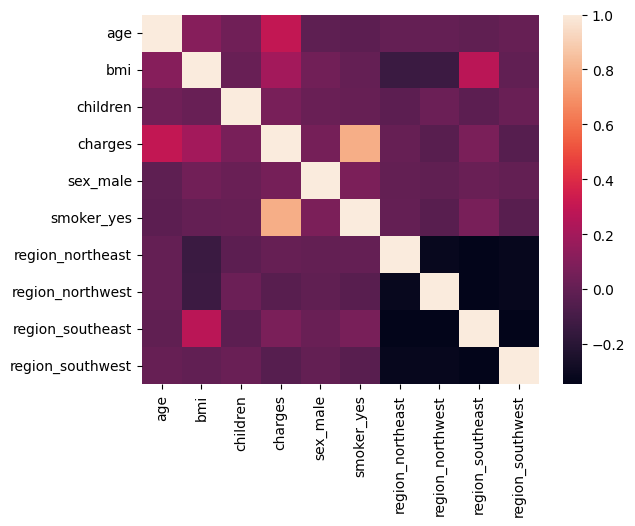

In [43]:
sns.heatmap(corr)

In [44]:
df.to_csv('../data/preprocessed/preprocessed_data.csv')